# **Bu analiz tarafımca kendimi geliştirmek amacıyla yapılmıştır. Sayfanın altında kendi raporumu ve yapay zekanın bana önerdiği yorumları görebilirsiniz.**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# **Senaryo:**

"EcoMarket" E-Ticaret Analizi Şirketimiz 2023 yılında farklı bölgelerde ve kategorilerde satış yaptı. Ancak pazarlama bütçemizi nereye odaklamamız gerektiği ve hangi kategorilerin aslında daha verimli olduğu konusunda kafamız karışık.

## **Veri Seti İçeriği (ecommerce_satis_verisi.csv)**

Veri seti 500 satırdan oluşuyor ve şu sütunları içeriyor:

*Tarih:*  Satışın yapıldığı gün.

*Kategori:* Elektronik, Giyim, Ev & Yaşam, Kozmetik.

*Bölge:* Marmara, Ege, İç Anadolu, Akdeniz.

*Satış_Adedi:* Kaç adet ürün satıldı?

*Birim_Fiyat:* Ürünün tekil fiyatı.

*Pazarlama_Harcaması:* O gün o kategori için yapılan reklam harcaması.

*Müşteri_Memnuniyeti_Puanı:* 1'den 5'e kadar müşteri geri bildirimi.

*Toplam_Satış:* Satış Adedi x Birim Fiyat.

**Senden Beklentilerim (Yönetici Özeti):**

*Genel Durum:*

2023 yılında toplam ciro ne kadar ve en çok hangi kategoriden para kazandık?

*Verimlilik:*

Pazarlama harcamalarımızın geri dönüşü (ROI) nasıl? Hangi kategoride reklam yapmak daha mantıklı?

*Bölgesel Farklar:*

Hangi bölge "yıldız", hangi bölge zayıf kalmış?

*Müşteri Sesi:*

Memnuniyet puanı ile satışlar arasında bir bağ var mı?

*Öneriler:*

2024 yılı için bana 3 tane somut tavsiye ver.

In [7]:
#dosyayı okuması için

file_path = r"/content/drive/MyDrive/Colab Notebooks/Pandas Denemelerim/ecommerce_satis_verisi.csv"
df=pd.read_csv(file_path)   #file_path olarak linklediğim dosyayı "df" ye yüklüyor. DF çağırıldığında liste gelir.
df

,Tarih,Kategori,Bölge,Satış_Adedi,Birim_Fiyat,Pazarlama_Harcaması,Müşteri_Memnuniyeti_Puanı,Toplam_Satış
0,2023-01-01,Ev & Yaşam,İç Anadolu,17,552.20,446.02,2,9387.40
1,2023-01-02,Kozmetik,Marmara,9,553.08,1600.43,2,4977.72
2,2023-01-03,Elektronik,Marmara,33,1119.38,1351.54,5,36939.54
3,2023-01-04,Ev & Yaşam,Akdeniz,20,705.72,1046.57,4,14114.40
4,2023-01-05,Ev & Yaşam,İç Anadolu,13,375.68,1155.19,4,4883.84
...,...,...,...,...,...,...,...,...
495,2024-05-10,Ev & Yaşam,Marmara,35,281.34,330.63,5,9846.90
496,2024-05-11,Ev & Yaşam,Marmara,25,1314.09,1268.52,3,32852.25
497,2024-05-12,Kozmetik,Akdeniz,26,367.86,1571.80,1,9564.36
498,2024-05-13,Elektronik,Akdeniz,11,1465.00,1323.42,3,16115.00


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Tarih                      500 non-null    object 
 1   Kategori                   500 non-null    object 
 2   Bölge                      500 non-null    object 
 3   Satış_Adedi                500 non-null    int64  
 4   Birim_Fiyat                500 non-null    float64
 5   Pazarlama_Harcaması        500 non-null    float64
 6   Müşteri_Memnuniyeti_Puanı  500 non-null    int64  
 7   Toplam_Satış               500 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 31.4+ KB


In [9]:
#Burada tarih "object" olarak gözüktüğü için onu düzeltmemiz gerekir.
df["Tarih"].dtype #Şu an 0 gözükecektir.

dtype('O')

In [10]:
df["Tarih"]

,Tarih
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
495,2024-05-10
496,2024-05-11
497,2024-05-12
498,2024-05-13


In [11]:
df["Tarih"]

,Tarih
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
495,2024-05-10
496,2024-05-11
497,2024-05-12
498,2024-05-13


In [12]:
df['Tarih']=pd.to_datetime(df['Tarih'])
df['Tarih']

,Tarih
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
495,2024-05-10
496,2024-05-11
497,2024-05-12
498,2024-05-13


In [13]:
df["Ay"] = df["Tarih"].dt.month_name()
df["Ay"]

,Ay
0,January
1,January
2,January
3,January
4,January
...,...
495,May
496,May
497,May
498,May


In [14]:
df["Tarih"].dtype

dtype('<M8[ns]')

In [15]:
df["Gün"] = df["Tarih"].dt.day_name()
df["Gün"]

,Gün
0,Sunday
1,Monday
2,Tuesday
3,Wednesday
4,Thursday
...,...
495,Friday
496,Saturday
497,Sunday
498,Monday


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Tarih                      500 non-null    datetime64[ns]
 1   Kategori                   500 non-null    object        
 2   Bölge                      500 non-null    object        
 3   Satış_Adedi                500 non-null    int64         
 4   Birim_Fiyat                500 non-null    float64       
 5   Pazarlama_Harcaması        500 non-null    float64       
 6   Müşteri_Memnuniyeti_Puanı  500 non-null    int64         
 7   Toplam_Satış               500 non-null    float64       
 8   Ay                         500 non-null    object        
 9   Gün                        500 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 39.2+ KB


In [17]:
df

,Tarih,Kategori,Bölge,Satış_Adedi,Birim_Fiyat,Pazarlama_Harcaması,Müşteri_Memnuniyeti_Puanı,Toplam_Satış,Ay,Gün
0,2023-01-01,Ev & Yaşam,İç Anadolu,17,552.20,446.02,2,9387.40,January,Sunday
1,2023-01-02,Kozmetik,Marmara,9,553.08,1600.43,2,4977.72,January,Monday
2,2023-01-03,Elektronik,Marmara,33,1119.38,1351.54,5,36939.54,January,Tuesday
3,2023-01-04,Ev & Yaşam,Akdeniz,20,705.72,1046.57,4,14114.40,January,Wednesday
4,2023-01-05,Ev & Yaşam,İç Anadolu,13,375.68,1155.19,4,4883.84,January,Thursday
...,...,...,...,...,...,...,...,...,...,...
495,2024-05-10,Ev & Yaşam,Marmara,35,281.34,330.63,5,9846.90,May,Friday
496,2024-05-11,Ev & Yaşam,Marmara,25,1314.09,1268.52,3,32852.25,May,Saturday
497,2024-05-12,Kozmetik,Akdeniz,26,367.86,1571.80,1,9564.36,May,Sunday
498,2024-05-13,Elektronik,Akdeniz,11,1465.00,1323.42,3,16115.00,May,Monday


Şu an verileri ay - gün şeklinde böldük.

Şimdi de bölge bazlı ayrı veri setleri elde edelim;

In [18]:
df_Marmara = df[df["Bölge"] == "Marmara"]

df_Marmara

,Tarih,Kategori,Bölge,Satış_Adedi,Birim_Fiyat,Pazarlama_Harcaması,Müşteri_Memnuniyeti_Puanı,Toplam_Satış,Ay,Gün
1,2023-01-02,Kozmetik,Marmara,9,553.08,1600.43,2,4977.72,January,Monday
2,2023-01-03,Elektronik,Marmara,33,1119.38,1351.54,5,36939.54,January,Tuesday
5,2023-01-06,Kozmetik,Marmara,28,706.04,1466.48,3,19769.12,January,Friday
10,2023-01-11,Ev & Yaşam,Marmara,35,1376.53,479.13,2,48178.55,January,Wednesday
30,2023-01-31,Elektronik,Marmara,25,103.00,1811.33,2,2575.00,January,Tuesday
...,...,...,...,...,...,...,...,...,...,...
466,2024-04-11,Kozmetik,Marmara,49,872.93,1073.22,1,42773.57,April,Thursday
472,2024-04-17,Ev & Yaşam,Marmara,40,972.82,235.39,3,38912.80,April,Wednesday
483,2024-04-28,Giyim,Marmara,36,1231.50,286.95,4,44334.00,April,Sunday
495,2024-05-10,Ev & Yaşam,Marmara,35,281.34,330.63,5,9846.90,May,Friday


In [19]:
df_Ege = df[df["Bölge"] == "Ege"]

df_Ege

,Tarih,Kategori,Bölge,Satış_Adedi,Birim_Fiyat,Pazarlama_Harcaması,Müşteri_Memnuniyeti_Puanı,Toplam_Satış,Ay,Gün
9,2023-01-10,Giyim,Ege,46,657.44,1335.62,4,30242.24,January,Tuesday
11,2023-01-12,Ev & Yaşam,Ege,6,575.47,1392.43,3,3452.82,January,Thursday
13,2023-01-14,Ev & Yaşam,Ege,5,966.78,158.24,1,4833.90,January,Saturday
14,2023-01-15,Kozmetik,Ege,47,68.99,589.60,2,3242.53,January,Sunday
17,2023-01-18,Kozmetik,Ege,10,1443.55,1481.62,3,14435.50,January,Wednesday
...,...,...,...,...,...,...,...,...,...,...
479,2024-04-24,Kozmetik,Ege,37,1312.91,1571.84,1,48577.67,April,Wednesday
485,2024-04-30,Giyim,Ege,1,1347.48,1552.31,4,1347.48,April,Tuesday
488,2024-05-03,Elektronik,Ege,21,705.86,256.13,4,14823.06,May,Friday
490,2024-05-05,Kozmetik,Ege,9,813.28,661.35,1,7319.52,May,Sunday


In [20]:
df_İcAnadolu = df[df["Bölge"] == "İç Anadolu"]

df_İcAnadolu

,Tarih,Kategori,Bölge,Satış_Adedi,Birim_Fiyat,Pazarlama_Harcaması,Müşteri_Memnuniyeti_Puanı,Toplam_Satış,Ay,Gün
0,2023-01-01,Ev & Yaşam,İç Anadolu,17,552.20,446.02,2,9387.40,January,Sunday
4,2023-01-05,Ev & Yaşam,İç Anadolu,13,375.68,1155.19,4,4883.84,January,Thursday
7,2023-01-08,Elektronik,İç Anadolu,29,305.76,1993.03,5,8867.04,January,Sunday
12,2023-01-13,Ev & Yaşam,İç Anadolu,18,891.85,237.18,2,16053.30,January,Friday
15,2023-01-16,Elektronik,İç Anadolu,25,1012.13,978.98,1,25303.25,January,Monday
...,...,...,...,...,...,...,...,...,...,...
464,2024-04-09,Kozmetik,İç Anadolu,8,625.54,385.32,3,5004.32,April,Tuesday
469,2024-04-14,Kozmetik,İç Anadolu,9,340.22,261.10,1,3061.98,April,Sunday
471,2024-04-16,Kozmetik,İç Anadolu,14,201.62,236.96,3,2822.68,April,Tuesday
473,2024-04-18,Kozmetik,İç Anadolu,41,1074.39,123.01,2,44049.99,April,Thursday


In [21]:
df_Akdeniz = df[df["Bölge"] == "Akdeniz"]

df_Akdeniz

,Tarih,Kategori,Bölge,Satış_Adedi,Birim_Fiyat,Pazarlama_Harcaması,Müşteri_Memnuniyeti_Puanı,Toplam_Satış,Ay,Gün
3,2023-01-04,Ev & Yaşam,Akdeniz,20,705.72,1046.57,4,14114.40,January,Wednesday
6,2023-01-07,Elektronik,Akdeniz,48,254.24,534.06,2,12203.52,January,Saturday
8,2023-01-09,Ev & Yaşam,Akdeniz,13,772.63,1952.11,5,10044.19,January,Monday
16,2023-01-17,Kozmetik,Akdeniz,2,308.15,1749.72,1,616.30,January,Tuesday
18,2023-01-19,Kozmetik,Akdeniz,30,265.56,1511.14,4,7966.80,January,Thursday
...,...,...,...,...,...,...,...,...,...,...
491,2024-05-06,Elektronik,Akdeniz,9,1110.80,1561.52,1,9997.20,May,Monday
493,2024-05-08,Giyim,Akdeniz,26,137.51,825.69,1,3575.26,May,Wednesday
494,2024-05-09,Elektronik,Akdeniz,41,408.30,490.81,3,16740.30,May,Thursday
497,2024-05-12,Kozmetik,Akdeniz,26,367.86,1571.80,1,9564.36,May,Sunday


Tüm veriyi, bölge bölge ayırmış olduk.

Tüm veri setinde, hangi bölgede en çok satış yapılmış;

In [22]:
df.groupby("Bölge")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Bölge,
İç Anadolu,2250791.84
Ege,2350459.94
Akdeniz,2383101.75
Marmara,2609125.44


<Axes: title={'center': 'Bölgelere Göre Toplam Satış Tutarı Grafiği'}, xlabel='Bölge', ylabel='Toplam Satış Tutarı'>

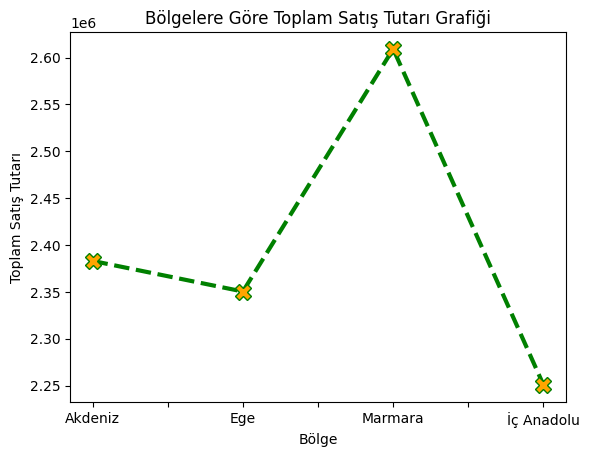

In [23]:
df.groupby("Bölge")["Toplam_Satış"].sum().plot( xlabel = "Bölge" , ylabel = "Toplam Satış Tutarı", fontsize= 10, title = "Bölgelere Göre Toplam Satış Tutarı Grafiği", color = "green" , linestyle= "dashed", linewidth = 3, marker = "X", markerfacecolor = "orange", markersize = 12)

In [24]:
df.groupby("Bölge")["Satış_Adedi"].sum()

,Satış_Adedi
Bölge,
Akdeniz,3073
Ege,3021
Marmara,3338
İç Anadolu,2896


<Axes: title={'center': 'Bölgelere Göre Satış Adedi'}, xlabel='Bölgeler', ylabel='Satış Adetleri'>

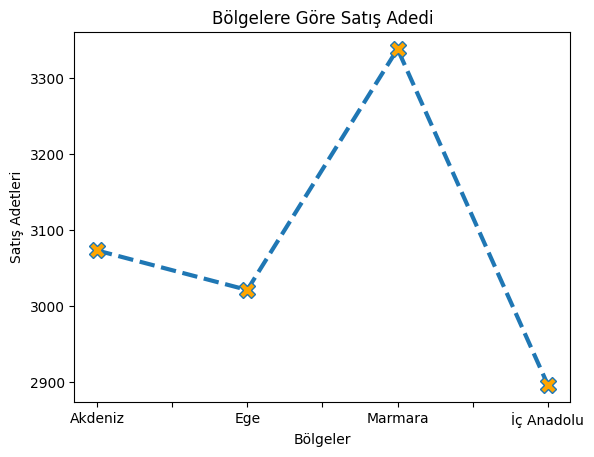

In [25]:
df.groupby("Bölge")["Satış_Adedi"].sum().plot(title = "Bölgelere Göre Satış Adedi", xlabel = "Bölgeler",  ylabel = "Satış Adetleri", linestyle = "dashed",linewidth = 3, marker = "X", markerfacecolor = "orange", markersize = 12)

In [26]:
df.groupby("Kategori")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Kategori,
Elektronik,2114133.72
Giyim,2192741.20
Ev & Yaşam,2328621.49
Kozmetik,2957982.56


<Axes: title={'center': 'Kategori Bazlı Toplam Satış'}, xlabel='Kategori', ylabel='Toplam Satış'>

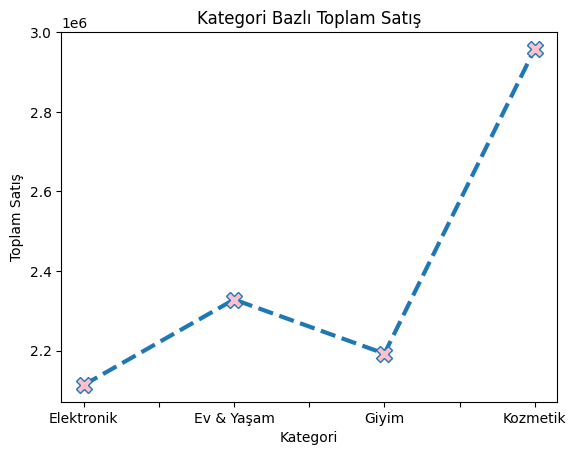

In [27]:
df.groupby("Kategori")["Toplam_Satış"].sum().plot(title = "Kategori Bazlı Toplam Satış", xlabel = "Kategori",  ylabel = "Toplam Satış", linestyle = "dashed",linewidth = 3, marker = "X", markerfacecolor = "pink", markersize = 12)

In [28]:
df.groupby(["Bölge","Kategori"])["Toplam_Satış"].sum()

Bölge       Kategori  
Akdeniz     Elektronik    603612.63
            Ev & Yaşam    498621.87
            Giyim         654525.66
            Kozmetik      626341.59
Ege         Elektronik    532915.35
            Ev & Yaşam    720978.19
            Giyim         416435.91
            Kozmetik      680130.49
Marmara     Elektronik    579614.58
            Ev & Yaşam    538011.33
            Giyim         581067.47
            Kozmetik      910432.06
İç Anadolu  Elektronik    397991.16
            Ev & Yaşam    571010.10
            Giyim         540712.16
            Kozmetik      741078.42
Name: Toplam_Satış, dtype: float64

<Axes: title={'center': 'Marmara Bölgesi - Kategori Dağılımı\n'}>

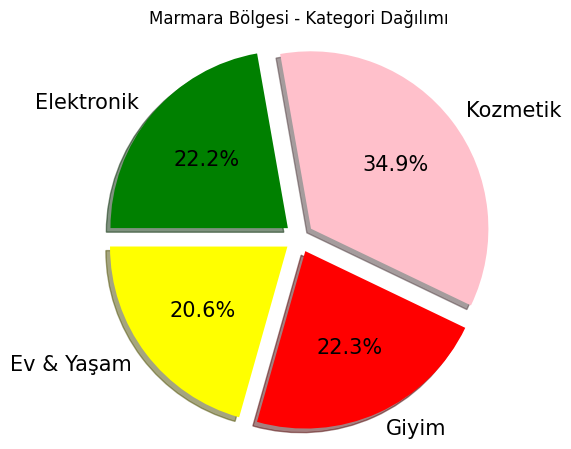

In [29]:
colors = ['green', 'yellow', 'red', 'pink']

df_Marmara.groupby("Kategori")["Toplam_Satış"].sum().plot(title = "Marmara Bölgesi - Kategori Dağılımı\n" , ylabel = "",kind = "pie", colors = colors, startangle=100, shadow = True, explode = (0.1, 0.1, 0.1, 0.1), radius = 1.2, autopct = '%1.1f%%', textprops={'fontsize': 15})

<Axes: title={'center': 'Akdeniz Bölgesi - Kategori Dağılımı\n'}>

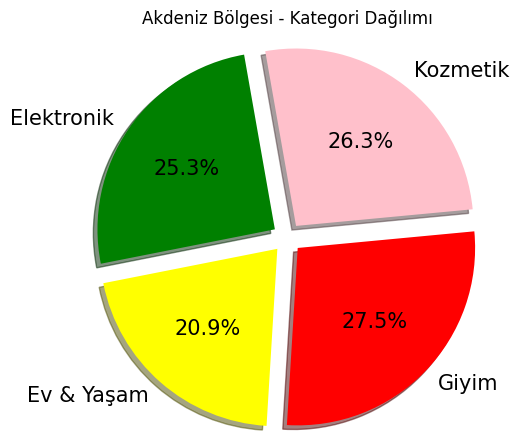

In [30]:
colors = ['green', 'yellow', 'red', 'pink']

df_Akdeniz.groupby("Kategori")["Toplam_Satış"].sum().plot(title = "Akdeniz Bölgesi - Kategori Dağılımı\n" , ylabel = "",kind = "pie", colors = colors, startangle=100, shadow = True, explode = (0.1, 0.1, 0.1, 0.1), radius = 1.2, autopct = '%1.1f%%', textprops={'fontsize': 15})

<Axes: title={'center': 'Ege Bölgesi - Kategori Dağılımı\n'}>

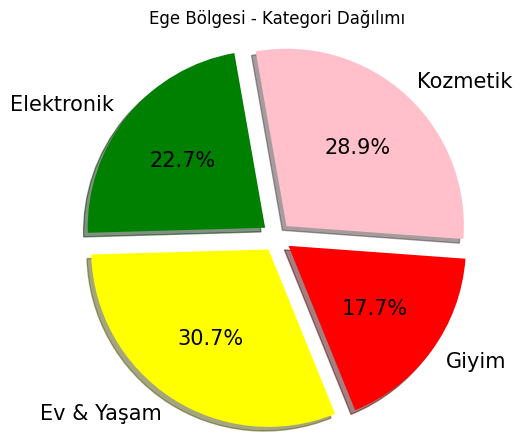

In [31]:
colors = ['green', 'yellow', 'red', 'pink']

df_Ege.groupby("Kategori")["Toplam_Satış"].sum().plot(title = "Ege Bölgesi - Kategori Dağılımı\n" , ylabel = "",kind = "pie", colors = colors, startangle=100, shadow = True, explode = (0.1, 0.1, 0.1, 0.1), radius = 1.2, autopct = '%1.1f%%', textprops={'fontsize': 15})

<Axes: title={'center': 'İç Anadolu Bölgesi - Kategori Dağılımı\n'}>

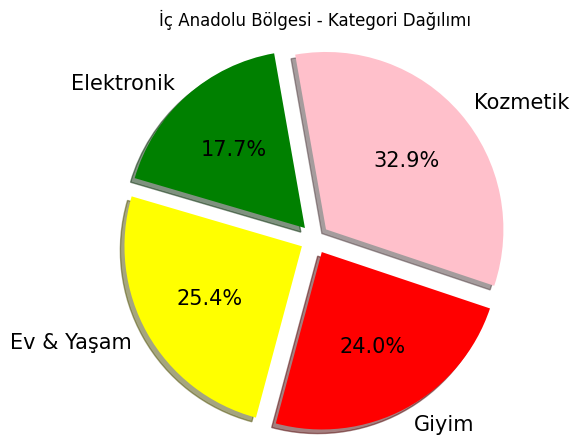

In [32]:
colors = ['green', 'yellow', 'red', 'pink']

df_İcAnadolu.groupby("Kategori")["Toplam_Satış"].sum().plot(title = "İç Anadolu Bölgesi - Kategori Dağılımı\n" , ylabel = "",kind = "pie", colors = colors, startangle=100, shadow = True, explode = (0.1, 0.1, 0.1, 0.1), radius = 1.2, autopct = '%1.1f%%', textprops={'fontsize': 15})

In [33]:
df_Marmara.groupby("Kategori")["Toplam_Satış"].describe()

,count,mean,std,min,25%,50%,75%,max
Kategori,,,,,,,,
Elektronik,32.0,18112.955625,16331.787759,440.20,5622.4725,13860.21,29562.6275,59487.60
Ev & Yaşam,31.0,17355.204194,15477.128783,1303.72,4671.5600,10182.48,26854.9350,51010.56
Giyim,28.0,20752.409643,20116.739297,801.95,5765.9050,13225.63,38655.9000,65105.81
Kozmetik,45.0,20231.823556,16760.789421,242.52,6677.7200,19769.12,28867.8200,71304.80


In [34]:
df_Ege.groupby("Kategori")["Toplam_Satış"].describe()

,count,mean,std,min,25%,50%,75%,max
Kategori,,,,,,,,
Elektronik,32.0,16653.604687,16442.435773,534.65,4089.69,9255.64,28205.370,65282.74
Ev & Yaşam,35.0,20599.376857,18873.945243,623.66,5362.90,14075.67,37787.700,61397.12
Giyim,24.0,17351.496250,16365.490908,490.70,3226.08,13303.15,28457.360,54250.24
Kozmetik,31.0,21939.693226,17819.699387,766.86,7904.26,15482.61,34249.265,61437.18


In [35]:
df_İcAnadolu.groupby("Kategori")["Toplam_Satış"].describe()

,count,mean,std,min,25%,50%,75%,max
Kategori,,,,,,,,
Elektronik,24.0,16582.965000,14240.464172,329.70,4952.4700,10961.055,26120.6525,49350.51
Ev & Yaşam,27.0,21148.522222,18467.866406,341.52,6163.3350,16053.300,31768.0150,63404.10
Giyim,26.0,20796.621538,17778.267171,829.26,7927.7325,15653.780,25467.3800,65347.39
Kozmetik,33.0,22456.921818,18697.455018,475.70,8535.6000,16931.470,30889.3400,72369.08


In [36]:
df_Akdeniz.groupby("Kategori")["Toplam_Satış"].describe()

,count,mean,std,min,25%,50%,75%,max
Kategori,,,,,,,,
Elektronik,34.0,17753.312647,15628.139655,1697.19,3741.5175,14449.900,25012.900,52648.20
Ev & Yaşam,29.0,17193.857586,17221.947935,437.19,2107.6000,12291.750,23551.580,55721.25
Giyim,30.0,21817.522000,15347.660730,868.80,10317.9800,21194.025,31225.965,53019.12
Kozmetik,39.0,16060.040769,14703.118700,616.30,5086.9400,9564.360,25960.040,57357.00


In [45]:
df_Marmara.groupby("Kategori")["Müşteri_Memnuniyeti_Puanı"].value_counts()

Kategori    Müşteri_Memnuniyeti_Puanı
Elektronik  4                             9
            2                             8
            1                             6
            5                             5
            3                             4
Ev & Yaşam  2                            10
            3                             6
            4                             6
            5                             6
            1                             3
Giyim       4                             9
            1                             6
            2                             6
            5                             4
            3                             3
Kozmetik    1                            13
            3                            12
            2                             8
            4                             7
            5                             5
Name: count, dtype: int64

In [70]:
df_Marmara.groupby("Kategori")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Kategori,
Ev & Yaşam,538011.33
Elektronik,579614.58
Giyim,581067.47
Kozmetik,910432.06


In [40]:
df_Ege.groupby("Kategori")["Müşteri_Memnuniyeti_Puanı"].value_counts()

Kategori    Müşteri_Memnuniyeti_Puanı
Elektronik  5                            11
            1                             7
            3                             6
            2                             5
            4                             3
Ev & Yaşam  1                             8
            3                             8
            5                             8
            2                             6
            4                             5
Giyim       2                             6
            5                             6
            3                             5
            4                             5
            1                             2
Kozmetik    4                             8
            1                             6
            2                             6
            3                             6
            5                             5
Name: count, dtype: int64

In [69]:
df_Ege.groupby("Kategori")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Kategori,
Giyim,416435.91
Elektronik,532915.35
Kozmetik,680130.49
Ev & Yaşam,720978.19


In [42]:
df_İcAnadolu.groupby("Kategori")["Müşteri_Memnuniyeti_Puanı"].value_counts()

Kategori    Müşteri_Memnuniyeti_Puanı
Elektronik  2                             7
            1                             6
            4                             5
            3                             3
            5                             3
Ev & Yaşam  4                            11
            3                             5
            1                             4
            2                             4
            5                             3
Giyim       4                            10
            3                             7
            2                             4
            5                             3
            1                             2
Kozmetik    4                            10
            1                             8
            3                             8
            5                             4
            2                             3
Name: count, dtype: int64

In [71]:
df_İcAnadolu.groupby("Kategori")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Kategori,
Elektronik,397991.16
Giyim,540712.16
Ev & Yaşam,571010.10
Kozmetik,741078.42


In [43]:
df_Akdeniz.groupby("Kategori")["Müşteri_Memnuniyeti_Puanı"].value_counts()

Kategori    Müşteri_Memnuniyeti_Puanı
Elektronik  3                             9
            1                             7
            5                             7
            4                             6
            2                             5
Ev & Yaşam  3                             8
            5                             8
            4                             7
            2                             4
            1                             2
Giyim       1                             8
            3                             6
            5                             6
            2                             5
            4                             5
Kozmetik    4                            10
            1                             9
            5                             8
            2                             7
            3                             5
Name: count, dtype: int64

In [72]:
df_Akdeniz.groupby("Kategori")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Kategori,
Ev & Yaşam,498621.87
Elektronik,603612.63
Kozmetik,626341.59
Giyim,654525.66


In [74]:
df.groupby("Bölge")["Müşteri_Memnuniyeti_Puanı"].sum().sort_values()

,Müşteri_Memnuniyeti_Puanı
Bölge,
İç Anadolu,334
Ege,378
Marmara,391
Akdeniz,409


In [91]:
df_Marmara.groupby("Ay")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Ay,
July,89264.87
November,129461.70
December,149608.59
October,193382.33
June,213537.39
May,232531.61
March,233920.44
April,242203.83
August,247383.79


In [104]:
df_Ege.groupby("Ay")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Ay,
October,65771.52
August,78298.29
November,105479.64
September,120392.46
December,141492.09
May,155797.75
April,230803.50
June,233369.24
February,279282.06


In [105]:
df_İcAnadolu.groupby("Ay")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Ay,
June,63824.98
September,99621.74
May,108712.31
July,152622.66
October,164454.91
November,206427.08
August,207946.08
April,208945.44
December,213709.92


In [106]:
df_Akdeniz.groupby("Ay")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Ay,
September,11991.31
December,88646.78
November,126529.99
July,157502.17
June,181458.79
October,184672.95
January,199589.10
May,225928.29
March,226139.09


In [107]:
df.groupby("Ay")["Toplam_Satış"].sum().sort_values()

,Toplam_Satış
Ay,
September,484847.09
November,567898.41
December,593457.38
October,608281.71
June,692190.40
May,722969.96
July,737044.28
August,815723.19
February,1065558.72


In [121]:
df_Marmara.groupby(["Kategori","Ay"])["Müşteri_Memnuniyeti_Puanı"].sum().sort_values(ascending = False )

Kategori    Ay       
Kozmetik    March        28
            January      20
Ev & Yaşam  December     17
Kozmetik    February     17
Ev & Yaşam  May          15
Elektronik  March        13
            January      12
Giyim       October      12
            August       11
Ev & Yaşam  February     11
            July         11
Elektronik  September    11
Kozmetik    April        11
Elektronik  October      10
            May          10
Ev & Yaşam  April        10
Giyim       April        10
Kozmetik    May           9
Giyim       February      9
Elektronik  July          9
Ev & Yaşam  January       8
Elektronik  November      8
Giyim       November      8
Kozmetik    September     7
Giyim       June          7
            March         7
Kozmetik    October       6
Elektronik  December      6
            April         6
Giyim       January       6
Kozmetik    August        6
Ev & Yaşam  June          6
            October       6
Giyim       December      5
Elektronik  August        5
Kozmetik    December      4
            July          4
Elektronik  February      4
Ev & Yaşam  March         4
Kozmetik    June          4
Giyim       September     4
            May           4
Ev & Yaşam  September     3
            November      2
            August        2
Kozmetik    November      2
Elektronik  June          1
Name: Müşteri_Memnuniyeti_Puanı, dtype: int64

In [127]:
df.groupby(["Gün","Kategori"])["Toplam_Satış"].sum().sort_values()

Gün        Kategori  
Sunday     Ev & Yaşam    200450.22
Monday     Elektronik    204722.21
           Giyim         207721.97
Thursday   Elektronik    223894.39
Tuesday    Ev & Yaşam    244518.95
Saturday   Elektronik    256460.70
           Giyim         258366.08
Monday     Ev & Yaşam    273959.24
Tuesday    Giyim         279388.32
Sunday     Elektronik    299684.16
Friday     Elektronik    317301.38
Saturday   Ev & Yaşam    318292.96
           Kozmetik      331860.47
Friday     Ev & Yaşam    332080.76
           Giyim         352052.80
Sunday     Giyim         355729.87
Thursday   Giyim         363831.75
Friday     Kozmetik      371526.14
Sunday     Kozmetik      373882.01
Monday     Kozmetik      373889.01
Wednesday  Giyim         375650.41
Tuesday    Elektronik    404529.31
Wednesday  Elektronik    407541.57
           Ev & Yaşam    422272.26
           Kozmetik      428684.32
Thursday   Kozmetik      516054.85
           Ev & Yaşam    537047.10
Tuesday    Kozmetik      562085.76
Name: Toplam_Satış, dtype: float64

## **“EcoMarket” E-Ticaret Analizi - Rapor**

Yapılan analizlere göre toplam satış olarak en fazla ciroya sahip bölge Marmara bölgesidir.



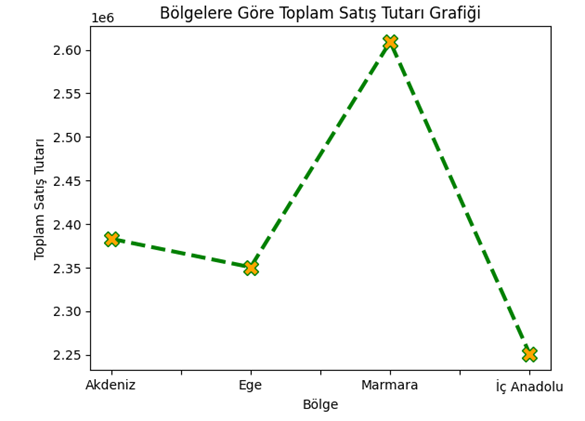






Bu satışların büyük bir çoğunluğunu “Kozmetik” kategorisi oluşturmaktadır. (910.432,06) En az ciro getiren kategori ise “Ev & Yaşam” dır (538.011,33).


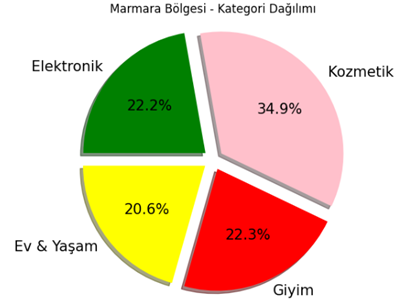




Kozmetik kategorisinin en yüksek ciro getirmesiyle birlikte, “Giyim” kategorisinde 28 kez işlem yapılmasına rağmen “Ev & Yaşam” kategorisine göre daha azdır.

Aynı zamanda Marmara bölgesi için en fazla 5 puanlık müşteri memnuniyet puanı alan kategori “Ev & Yaşam” kategorisidir. Böylece cirosu az olsa dahi yüksek puan alan bir kategoridir.
Buna kıyasla “Kozmetik” kategorisini incelediğimizde 1 ve 2 puanların çoğunlukta olduğunu gözlemliyoruz.


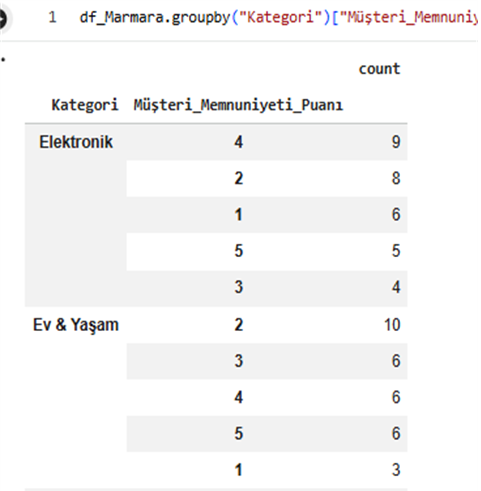


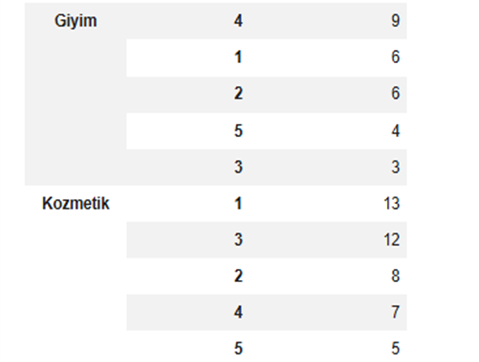


En yüksek müşteri memnuniyet puan toplamına sahip bölge “Akdeniz” bölgesidir.
Fakat ciroların kontrolü yapıldığında 2.sırada gelmektedir.

Tüm bölgeler ay bazında kontrol edildiğinde en fazla ciroyu Mart ayında alıyor.

Bunun büyük çoğunluğunu ise Mart ayı içerisinde İç Anadolu bölgesinden gelmektedir (348.889,79)

Bölge bazında aylık cirolar;

•	Marmara bölgesi için Ocak ayı 340.998,07

•	Ege bölgesi için Temmuz ayı 337.654,58

•	İç Anadolu bölgesi için Mart 348.889,79

•	Akdeniz bölgesi için Nisan 410.160,24

•  Genel Durum: 2023 yılında toplam ciro ne kadar ve en çok hangi kategoriden para kazandık?

En fazla ciro “Kozmetik” kategorisinden gelmektedir.

•  Verimlilik: Pazarlama harcamalarımızın geri dönüşü (ROI) nasıl? Hangi kategoride reklam yapmak daha mantıklı?

“Kozmetik” kategorisinden reklam harcaması yapmak daha iyi olabilir.

•  Bölgesel Farklar: Hangi bölge "yıldız", hangi bölge zayıf kalmış?

İç Anadolu bölgesinde ciro diğer bölgelere kıyasla düşük kalmıştır.

•  Müşteri Sesi: Memnuniyet puanı ile satışlar arasında bir bağ var mı?

Memnuniyet puanı ile satışlar arasında bir bağ bulunmuyor, kozmetik kategorisi en fazla ciroya sahip olmasına rağmen en düşük puanlara sahip olan kategorilerin başında gelmektedir.

•  Öneriler: 2024 yılı için bana 3 tane somut tavsiye ver.

Kozmetik kategorisinde müşteri puanını yükseltmeye yönelik çalışmalar yapılmalı.

Salı günü “Kozmetik” sektöründe yoğunluk oluyor, bu sebeple çalışan sayılarını arttırmak, müşteri puanını da arttırır.

Standart sapmaları arasında bölge bazlı fark çok fazla yoktur. Bu sebeple çalışan sayılarını oranlamak ve reklamları arttırmak yeterli olacaktır.


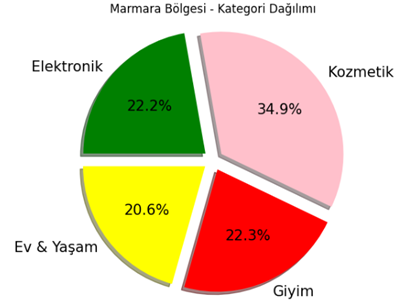

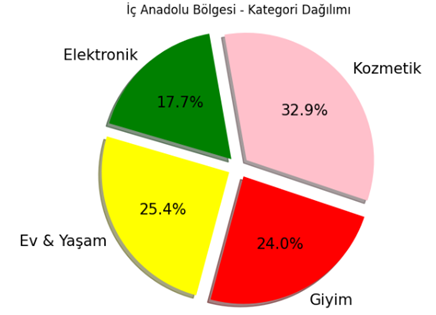

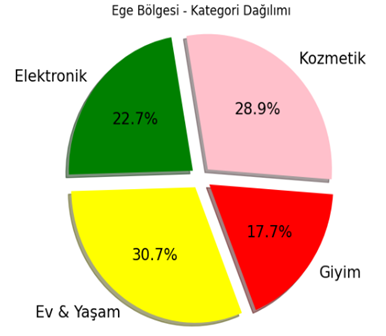

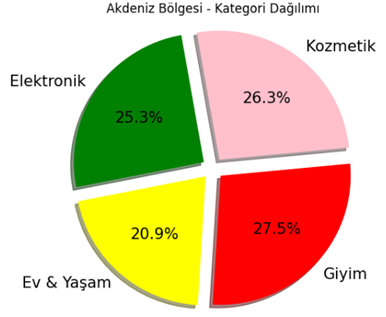


                       




# **Gemini Yorum**

Sayın Analist,

Öncelikle eline sağlık.

Raporunu ve grafiklerini detaylıca inceledim. Bir Satış ve Operasyon Direktörü olarak, sunduğun bu çalışmayı hem veriye dayalı olması hem de bazı "gizli" noktaları yakalamış olman açısından değerlendireceğim.İşte raporun hakkındaki geri bildirimlerim:
👍 Neleri Çok İyi Yaptın?

**(Yıldızlı Puanlar)Marmara-Kozmetik Paradoksu:**

Kozmetik kategorisinin en yüksek ciroyu getirmesine rağmen en düşük memnuniyet puanına (özellikle Marmara'da 13 kişinin 1 puan vermesi) sahip olduğunu yakalaman mükemmel.
Bu, yöneticiye "Çok satıyoruz ama müşteriyi kaybediyoruz, operasyonel bir sorun var" mesajını net verir.

**Haftalık Detay Analizi (Salı Günü Keşfi):**

Raporda bahsettiğin "Salı günü Kozmetik yoğunluğu" tespiti çok keskin bir gözlem. Veri setini derinlemesine incelediğini ve sadece yüzeydeki toplam rakamlara bakmadığını gösteriyor. Gerçekten de verilerde Salı günü Kozmetik satış adetlerinin zirve yaptığını (696 adet) görüyoruz.

Bu, personel planlaması için paha biçilemez bir bilgi.

**Görselleştirme:**

Grafiklerin sade ve okunur. Özellikle bölge bazlı pasta grafiklerin, her bölgenin kendi içindeki ağırlığını anlamamı kolaylaştırdı.

**⚠️ Eksikler ve "Yönetici Gözüyle" EleştirilerROI (Yatırım Getirisi) Yanılgısı:**

"Kozmetik kategorisinde reklam yapmak daha mantıklı" demişsin. Ancak bir yönetici olarak ben "en çok ciro yapan" değil, "harcadığım paraya karşılık en çok kazandıran" yeri bilmek isterim.

**Gerçek:**

Verilere göre Giyim kategorisinin ROI oranı ($19,08$), Kozmetik'ten ($18,64$) daha yüksektir. Yani Giyim'e harcadığımız her 1 TL, bize daha fazla kar bırakıyor.

Reklam bütçesini buraya kaydırmayı düşünmeliydin.

**Genel Toplam (Big Picture):**

Raporun başında bana 2023 yılının toplam cirosunu ($9.593.478,97$ TL) tek bir rakam olarak vermeni beklerdim. Bir yönetici önce "Kasadaki toplam para ne?" diye sorar, sonra detaylara iner.

**İç Anadolu Analizi:**

İç Anadolu'nun en zayıf halka olduğunu doğru tespit etmişsin ancak Mart ayındaki o devasa sıçramayı ($348.889,79$ TL) neden yaptığını sorgulamanı beklerdim. Bu geçici bir kampanya mıydı yoksa bir defalık büyük bir ihale mi?

**🎯 2024 İçin Stratejik Tavsiyelerim (Senin İçin Güncellenmiş Hal):**

Analizini bir adım öteye taşımak için şu 3 maddeyi eklemelisin:

*Kozmetik Operasyonu:* Salı günleri için Marmara bölgesindeki depoya/mağazaya ek personel desteği verilmeli (Senin de belirttiğin gibi).

*Verimlilik Odaklı Reklam:* Pazarlama bütçesinin bir kısmını ROI'si en yüksek olan Giyim kategorisine kaydırarak karlılığı artırmalıyız.

*Müşteri Deneyimi:* Kozmetik kategorisindeki düşük puanların sebebini (Kargo mu? Ürün kalitesi mi?) anlamak için bu 1 puan veren müşterilere yönelik bir anket başlatmalıyız.

***Yönetici Notu:***

Analiz yeteneğin ve detay yakalama becerin (özellikle o Salı günü tespiti!) çok yüksek. Sadece "toplam satış" ile "verimlilik (ROI)" arasındaki farka biraz daha dikkat etmelisin.

Puanım: 8.5/10 (Salı günü tespiti için +1 puan ekledim)

Bir sonraki analizde görüşmek üzere, harika iş!